In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os
import cv2

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
TensorFlow: 2.21.0


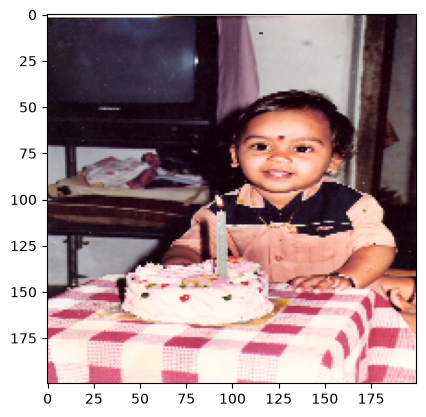

In [12]:
happy_path ="training/Happy"
img = image.load_img(happy_path + '/7.jpg', target_size=(200, 200))
plt.imshow(img)

In [13]:
training_datagen = ImageDataGenerator(rescale=1/200)
validation_datagen = ImageDataGenerator(rescale=1/200)

In [14]:
training_set = training_datagen.flow_from_directory('training',
                                                    target_size=(200, 200),
                                                    batch_size=32,
                                                    class_mode='binary')

validation_set = validation_datagen.flow_from_directory('validation',
                                                      target_size=(200, 200),
                                                      batch_size=32,
                                                      class_mode='binary')

Found 24 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [15]:
training_set.class_indices

{'Happy': 0, 'Sad': 1}

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [17]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy']) 

In [18]:
model.fit(training_set,
          epochs=20)

/Users/rojarani/Documents/AIML/GitAIML/Full-Stack-Data-Science-WIth-Gen-AI-and-Agentic-AI/.venv-tf/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 0.7349
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step - accuracy: 0.6667 - loss: 11.4656
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step - accuracy: 0.3333 - loss: 1.8492
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step - accuracy: 0.6667 - loss: 0.6121
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step - accuracy: 0.7083 - loss: 0.5586
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step - accuracy: 0.7083 - loss: 0.5124
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 943ms/step - accuracy: 0.7083 - loss: 0.4505
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step - accuracy: 0.7917 - loss: 0.3990
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step - accuracy: 0.6667 - loss: 1.2912
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step - accuracy: 0.3333 - loss: 0.9402
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step - accuracy: 0.7917 - loss: 0.4716
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step - accuracy: 0.7917 - loss

In [19]:
test_path = 'testing'
for i in os.listdir(test_path):
    print(i)

Gemini_Generated_Image_xj7o1sxj7o1sxj7o.png
IMG_20230107_094506 (1).jpg
.DS_Store
BHA_0388.JPG
Sad_Face_Emoji_large.webp
DSC_6116.JPG


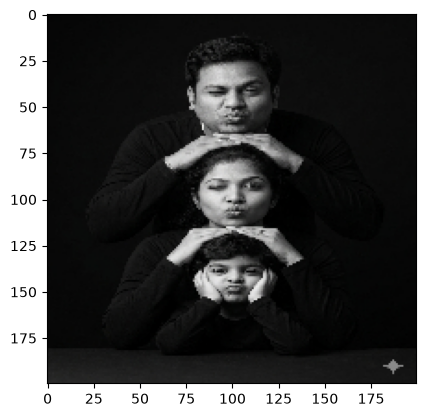

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[0.]
Gemini_Generated_Image_xj7o1sxj7o1sxj7o.png is a happy person


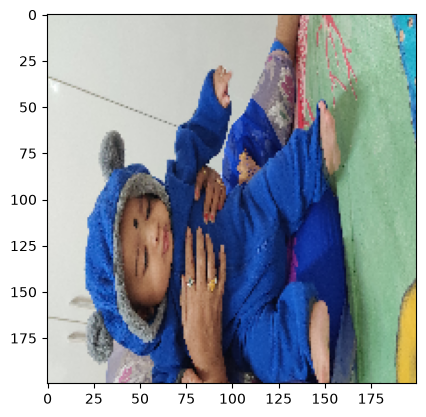

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.]
IMG_20230107_094506 (1).jpg is a happy person


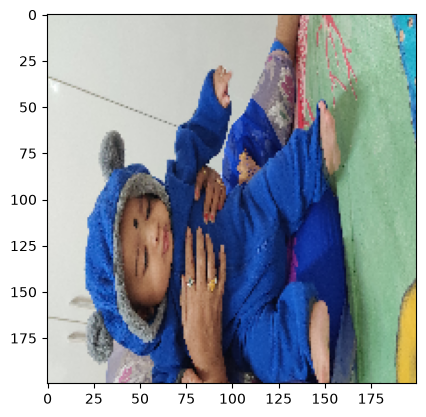

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[0.]
.DS_Store is a happy person


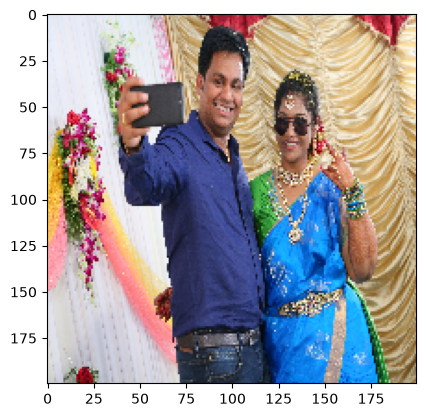

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.]
BHA_0388.JPG is a happy person


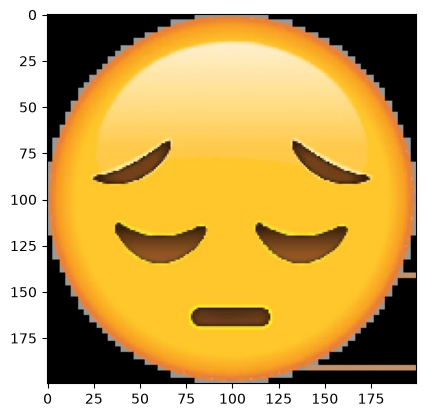

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.]
Sad_Face_Emoji_large.webp is a happy person


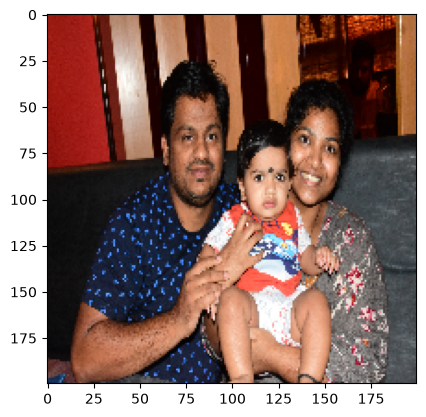

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.]
DSC_6116.JPG is a happy person


In [24]:
for i in os.listdir(test_path):
    if not i.startswith('.') and i.lower().endswith(('.jpg', '.jpeg', '.png','.webp')):
        img = image.load_img(test_path + '/' + i, target_size=(200, 200))
    plt.imshow(img)
    plt.show()
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)
    print(classes[0])
    if classes[0] < 0.5:
        print(i + " is a happy person")
    else:
        print(i + " is a sad person")
